### Buscar relación y comprobar si existe una relación entre la P med y el exponente de escala

In [7]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geopandas as gpd 
import seaborn as sns
import contextily as ctx
import mapclassify

In [8]:
estaciones=gpd.read_file(r"carto\estaciones_tag.gpkg")
estaciones.to_crs(epsg=9377)
estaciones.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Codigo           223 non-null    int32   
 1   Nombre estacion  223 non-null    str     
 2   Inicio           223 non-null    str     
 3   Fin              223 non-null    str     
 4   Latitud          223 non-null    float64 
 5   Longitud         223 non-null    float64 
 6   X                223 non-null    float64 
 7   Y                223 non-null    float64 
 8   Elevacion        223 non-null    int32   
 9   Departamento     223 non-null    str     
 10  % de faltantes   223 non-null    float64 
 11  Tendencia        223 non-null    str     
 12  Beta             223 non-null    float64 
 13  M24              223 non-null    float64 
 14  PP media         223 non-null    float64 
 15  cod_ah           223 non-null    float64 
 16  nom_ah           223 non-null    str

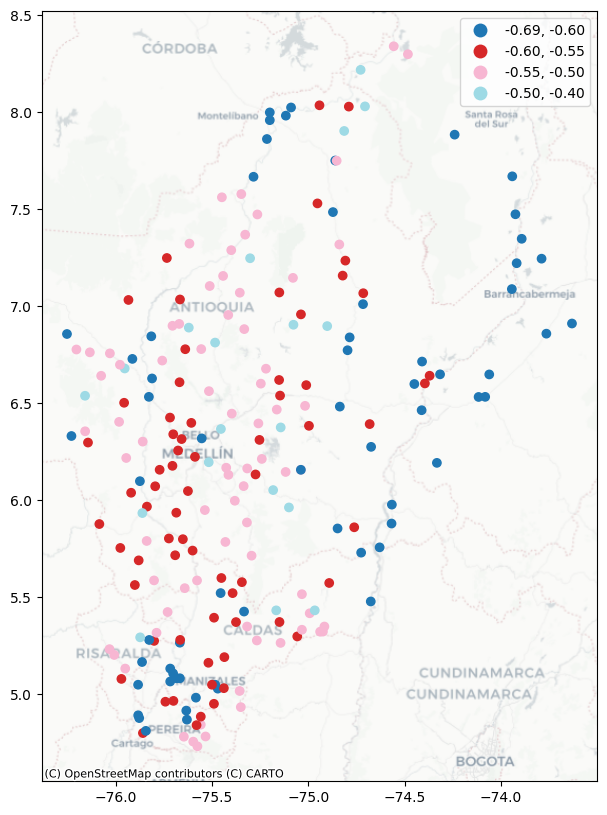

In [12]:
fig,ax=plt.subplots(figsize=(10,10))
estaciones.plot(ax=ax,column='Beta',categorical=True,cmap='tab20',scheme='NaturalBreaks',k=4,legend=True)
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron,crs=estaciones.crs)

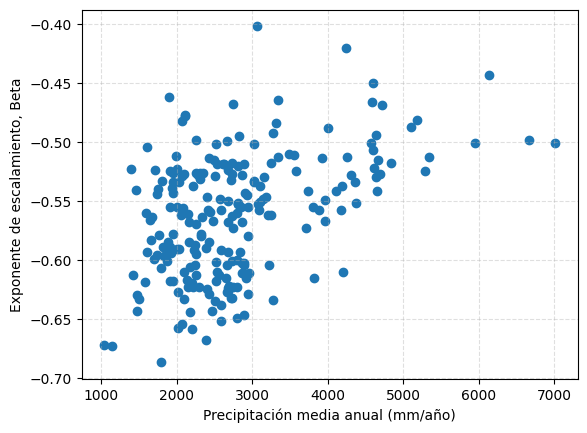

In [14]:
# Comparar gráfico de dispersión entre Beta y P media 
plt.scatter(estaciones["PP media"], estaciones["Beta"])

plt.xlabel("Precipitación media anual (mm/año)")
plt.ylabel("Exponente de escalamiento, Beta")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [ ]:
# Correlaciones
from scipy.stats import pearsonr, spearmanr

df = estaciones[["PP media", "Beta"]].dropna()

r_pearson, p_pearson = pearsonr(
    df["PP media"],
    df["Beta"]
)

r_spearman, p_spearman = spearmanr(
    df["PP media"],
    df["Beta"]
)

print("Pearson:", r_pearson, "p-valor:", p_pearson)
print("Spearman:", r_spearman, "p-valor:", p_spearman)

Pearson: 0.4557824340256962 p-valor: 7.733684357067274e-13
Spearman: 0.38648900477534015 p-valor: 2.3323136464769237e-09


Número de estaciones utilizadas: 223
Número óptimo según el método del codo: 5
Número óptimo según Silhouette: 3
Silhouette máximo: 0.442


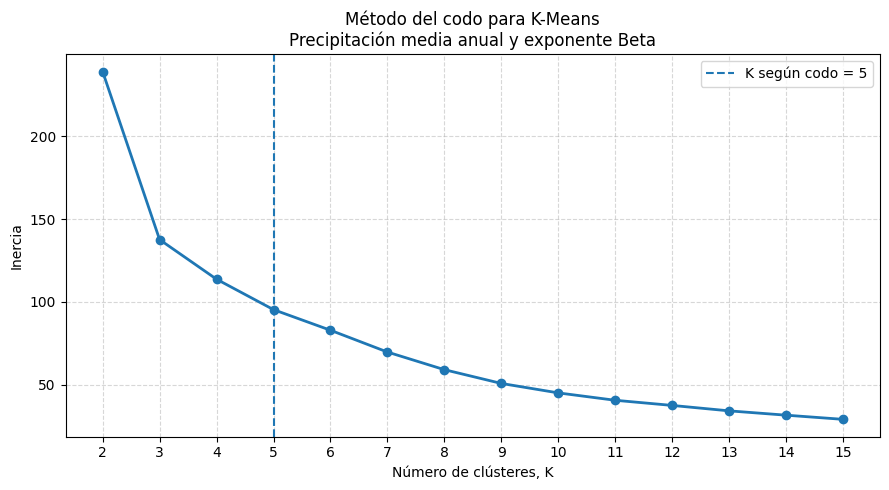

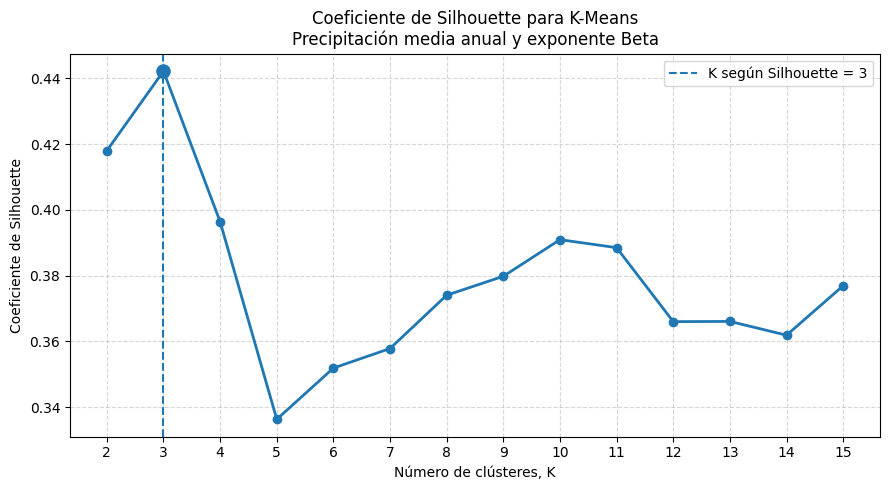

K seleccionado para el modelo final: 5


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# =====================================================
# 1. SELECCIONAR Y LIMPIAR LAS VARIABLES
# =====================================================

variables_cluster = ["PP media", "Beta"]

df_cluster = (
    estaciones[variables_cluster]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f"Número de estaciones utilizadas: {len(df_cluster)}")

# =====================================================
# 2. ESTANDARIZAR LAS VARIABLES
# =====================================================

scaler = StandardScaler()

X_std = scaler.fit_transform(
    df_cluster[variables_cluster]
)

# =====================================================
# 3. DEFINIR EL RANGO DE K
# =====================================================

# No se pueden evaluar más clústeres que observaciones.
# Para silhouette, K debe ser menor que el número de estaciones.
k_max = min(15, len(df_cluster) - 1)

if k_max < 2:
    raise ValueError(
        "No hay suficientes estaciones para realizar el clustering."
    )

rango_k = range(2, k_max + 1)

# =====================================================
# 4. CALCULAR INERCIA Y SILHOUETTE
# =====================================================

inercias = []
silhouettes = []

for k in rango_k:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    etiquetas = kmeans.fit_predict(X_std)

    inercias.append(kmeans.inertia_)

    silhouettes.append(
        silhouette_score(X_std, etiquetas)
    )

# =====================================================
# 5. ENCONTRAR K ÓPTIMO CON EL MÉTODO DEL CODO
# =====================================================

knee_finder = KneeLocator(
    list(rango_k),
    inercias,
    S=1.0,
    curve="convex",
    direction="decreasing"
)

k_codo = knee_finder.knee

# KneeLocator puede no detectar un codo claramente definido
if k_codo is None:
    print(
        "No se detectó un codo claramente definido "
        "mediante KneeLocator."
    )
else:
    print(
        f"Número óptimo según el método del codo: {k_codo}"
    )

# =====================================================
# 6. ENCONTRAR K ÓPTIMO CON SILHOUETTE
# =====================================================

indice_mejor = np.argmax(silhouettes)
k_silhouette = list(rango_k)[indice_mejor]
silhouette_max = silhouettes[indice_mejor]

print(
    f"Número óptimo según Silhouette: {k_silhouette}"
)

print(
    f"Silhouette máximo: {silhouette_max:.3f}"
)

# =====================================================
# 7. GRAFICAR MÉTODO DEL CODO
# =====================================================

plt.figure(figsize=(9, 5))

plt.plot(
    list(rango_k),
    inercias,
    marker="o",
    linewidth=2
)

if k_codo is not None:
    plt.axvline(
        x=k_codo,
        linestyle="--",
        linewidth=1.5,
        label=f"K según codo = {k_codo}"
    )

plt.title(
    "Método del codo para K-Means\n"
    "Precipitación media anual y exponente Beta"
)

plt.xlabel("Número de clústeres, K")
plt.ylabel("Inercia")
plt.xticks(list(rango_k))
plt.grid(True, linestyle="--", alpha=0.5)

if k_codo is not None:
    plt.legend()

plt.tight_layout()
plt.show()

# =====================================================
# 8. GRAFICAR COEFICIENTE DE SILHOUETTE
# =====================================================

plt.figure(figsize=(9, 5))

plt.plot(
    list(rango_k),
    silhouettes,
    marker="o",
    linewidth=2
)

plt.axvline(
    x=k_silhouette,
    linestyle="--",
    linewidth=1.5,
    label=f"K según Silhouette = {k_silhouette}"
)

plt.scatter(
    k_silhouette,
    silhouette_max,
    s=90,
    zorder=3
)

plt.title(
    "Coeficiente de Silhouette para K-Means\n"
    "Precipitación media anual y exponente Beta"
)

plt.xlabel("Número de clústeres, K")
plt.ylabel("Coeficiente de Silhouette")
plt.xticks(list(rango_k))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# =====================================================
# 9. SELECCIONAR EL K DEFINITIVO
# =====================================================

# Se prioriza el resultado del codo cuando fue identificado.
# Si KneeLocator no encuentra un codo, se utiliza Silhouette.

if k_codo is not None:
    k_optimo = k_codo
else:
    k_optimo = k_silhouette

print(f"K seleccionado para el modelo final: {k_optimo}")

# =====================================================
# 10. AJUSTAR EL MODELO FINAL
# =====================================================

modelo_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=20
)

df_cluster["Cluster"] = modelo_final.fit_predict(X_std)

# Se suma 1 para que los clústeres se numeren desde 1
df_cluster["Cluster"] = df_cluster["Cluster"] + 1

# Incorporar los resultados en el GeoDataFrame original
estaciones["Cluster"] = np.nan

estaciones.loc[
    df_cluster.index,
    "Cluster"
] = df_cluster["Cluster"]

estaciones["Cluster"] = estaciones["Cluster"].astype("Int64")


C:\Users\DAVID01\AppData\Local\Temp\ipykernel_9844\3406593307.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


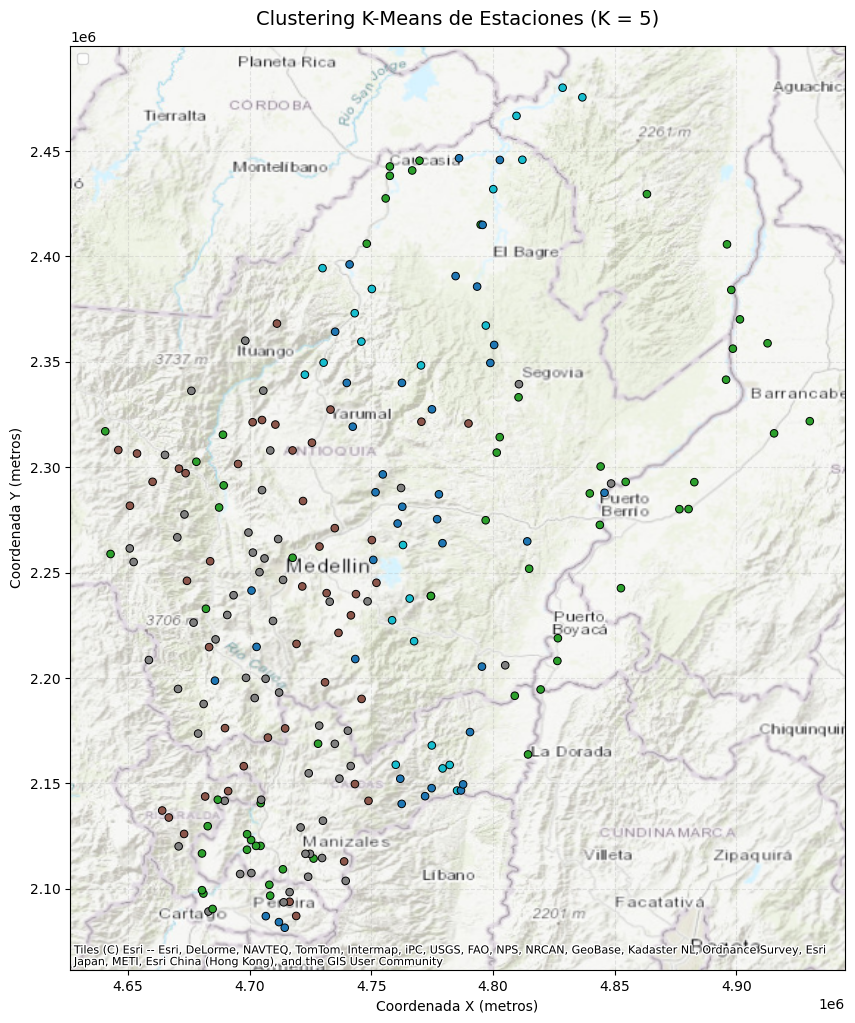

In [28]:
# 4. Graficar con mapa base
fig, ax = plt.subplots(figsize=(10, 12))

# Graficar las estaciones coloreadas por su clúster de K-Means
scatter = ax.scatter(
    estaciones['X'], 
    estaciones['Y'], 
    c=estaciones['Cluster'], 
    cmap='tab10', 
    s=30, 
    edgecolors='black', 
    linewidths=0.7,
    zorder=2
)

# Añadir mapa base (Asegúrate de usar el CRS de tus datos, ej. EPSG:9377)
ctx.add_basemap(ax, crs='epsg:9377', source=ctx.providers.Esri.WorldTopoMap, zorder=1)

# Detalles del mapa
#plt.colorbar(scatter, ax=ax, label="ID del Clúster K-Means", shrink=0.6)
ax.set_title(f"Clustering K-Means de Estaciones (K = {k_optimo})", fontsize=14, pad=15)
ax.set_xlabel("Coordenada X (metros)")
ax.set_ylabel("Coordenada Y (metros)")
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()